# Датасет и подготовка признаков

Ноутбук фиксирует фактический состав данных, session-level split и входное представление моделей.
Он использует реализацию из `src` и не дублирует код предобработки.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.dataset import (
    TEST_SESSIONS,
    TRAIN_SESSIONS,
    VALIDATION_SESSIONS,
    load_metadata,
    shift_with_zeros,
    split_metadata,
)
from src.preprocessing import CLASS_NAMES, LogMelExtractor, load_waveform

sns.set_theme(style="whitegrid")
metadata = load_metadata(ROOT / "metadata.csv")
splits = split_metadata(metadata)

## 1. Целостность датасета

Метаданные должны однозначно соответствовать WAV-файлам. Эти проверки защищают дальнейшие
эксперименты от пропавших файлов, повторов и несогласованных меток.

In [2]:
resolved_paths = [ROOT / "data" / "raw" / Path(value) for value in metadata["path"]]
wav_paths = list((ROOT / "data" / "raw").rglob("*.wav"))

integrity = pd.Series({
    "metadata rows": len(metadata),
    "WAV files": len(wav_paths),
    "duplicate metadata paths": int(metadata["path"].duplicated().sum()),
    "missing WAV files": sum(not path.is_file() for path in resolved_paths),
    "classes": metadata["class"].nunique(),
    "sessions": metadata["session"].nunique(),
}, name="value")
display(integrity.to_frame())

assert integrity["metadata rows"] == integrity["WAV files"] == 863
assert integrity["duplicate metadata paths"] == 0
assert integrity["missing WAV files"] == 0
assert tuple(sorted(metadata["class"].unique())) == CLASS_NAMES

,value
metadata rows,863
WAV files,863
duplicate metadata paths,0
missing WAV files,0
classes,5
sessions,8


## 2. Состав классов и сессий

Небольшой дисбаланс исходных записей учитывается через macro-F1. Сессия — единица разбиения,
поскольку записи одной сессии разделяют микрофон, помещение, расстояние и фон.

,files
class,
clap,160
knock,171
sing,175
spoon,181
whistle,176


class,clap,knock,sing,spoon,whistle
session,,,,,
s01_pc_near,20,20,20,20,20
s02_phone_near,19,19,24,26,22
s03_pc_far,20,20,20,20,20
s04_phone_far,21,32,25,27,20
s05_phone_r2_near,20,19,23,23,25
s06_pc_other_room,20,20,20,20,20
s07_phone_ambient,20,21,23,25,29
s08_pc_ambient,20,20,20,20,20


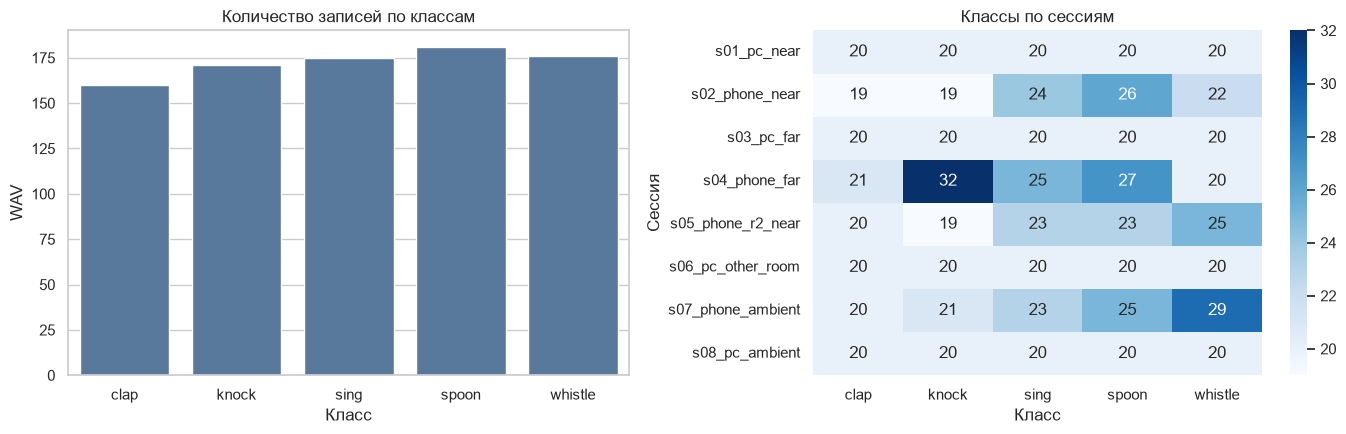

In [3]:
class_counts = metadata["class"].value_counts().reindex(CLASS_NAMES)
session_class_counts = pd.crosstab(metadata["session"], metadata["class"]).reindex(columns=CLASS_NAMES)
display(class_counts.rename("files").to_frame())
display(session_class_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], color="#4C78A8")
axes[0].set(title="Количество записей по классам", xlabel="Класс", ylabel="WAV")
sns.heatmap(session_class_counts, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set(title="Классы по сессиям", xlabel="Класс", ylabel="Сессия")
plt.tight_layout()

## 3. Session-level split

Используется одно фиксированное разбиение для всех сравниваемых моделей. Ни одна сессия и ни
один файл не встречаются одновременно в train, validation и test.

In [4]:
split_summary = []
for split_name, frame in splits.items():
    split_summary.append({
        "split": split_name,
        "files": len(frame),
        "sessions": ", ".join(sorted(frame["session"].unique())),
    })
display(pd.DataFrame(split_summary))
split_table = pd.concat(
    [frame.assign(split=name) for name, frame in splits.items()],
    ignore_index=True,
)
display(pd.crosstab(split_table["split"], split_table["class"], margins=True))

assert TRAIN_SESSIONS.isdisjoint(VALIDATION_SESSIONS | TEST_SESSIONS)
assert VALIDATION_SESSIONS.isdisjoint(TEST_SESSIONS)
assert [len(splits[name]) for name in ("train", "validation", "test")] == [653, 100, 110]

,split,files,sessions
0,train,653,"s02_phone_near, s03_pc_far, s04_phone_far, s06..."
1,validation,100,s01_pc_near
2,test,110,s05_phone_r2_near


class,clap,knock,sing,spoon,whistle,All
split,,,,,,
test,20,19,23,23,25,110
train,120,132,132,138,131,653
validation,20,20,20,20,20,100
All,160,171,175,181,176,863


## 4. Преобразование аудио в log-Mel

Единый pipeline: mono → 16 кГц → центральная обрезка или дополнение до 1,5 с →
log-Mel с 64 полосами. Ниже показано по одному train-примеру каждого класса.

,class,waveform shape,feature shape,min,max
0,clap,"(1, 24000)","(1, 64, 151)",-13.815511,3.832340
1,knock,"(1, 24000)","(1, 64, 151)",-13.815511,5.857454
2,sing,"(1, 24000)","(1, 64, 151)",-13.815511,5.642448
3,spoon,"(1, 24000)","(1, 64, 151)",-13.815511,4.757806
4,whistle,"(1, 24000)","(1, 64, 151)",-13.815511,6.939875


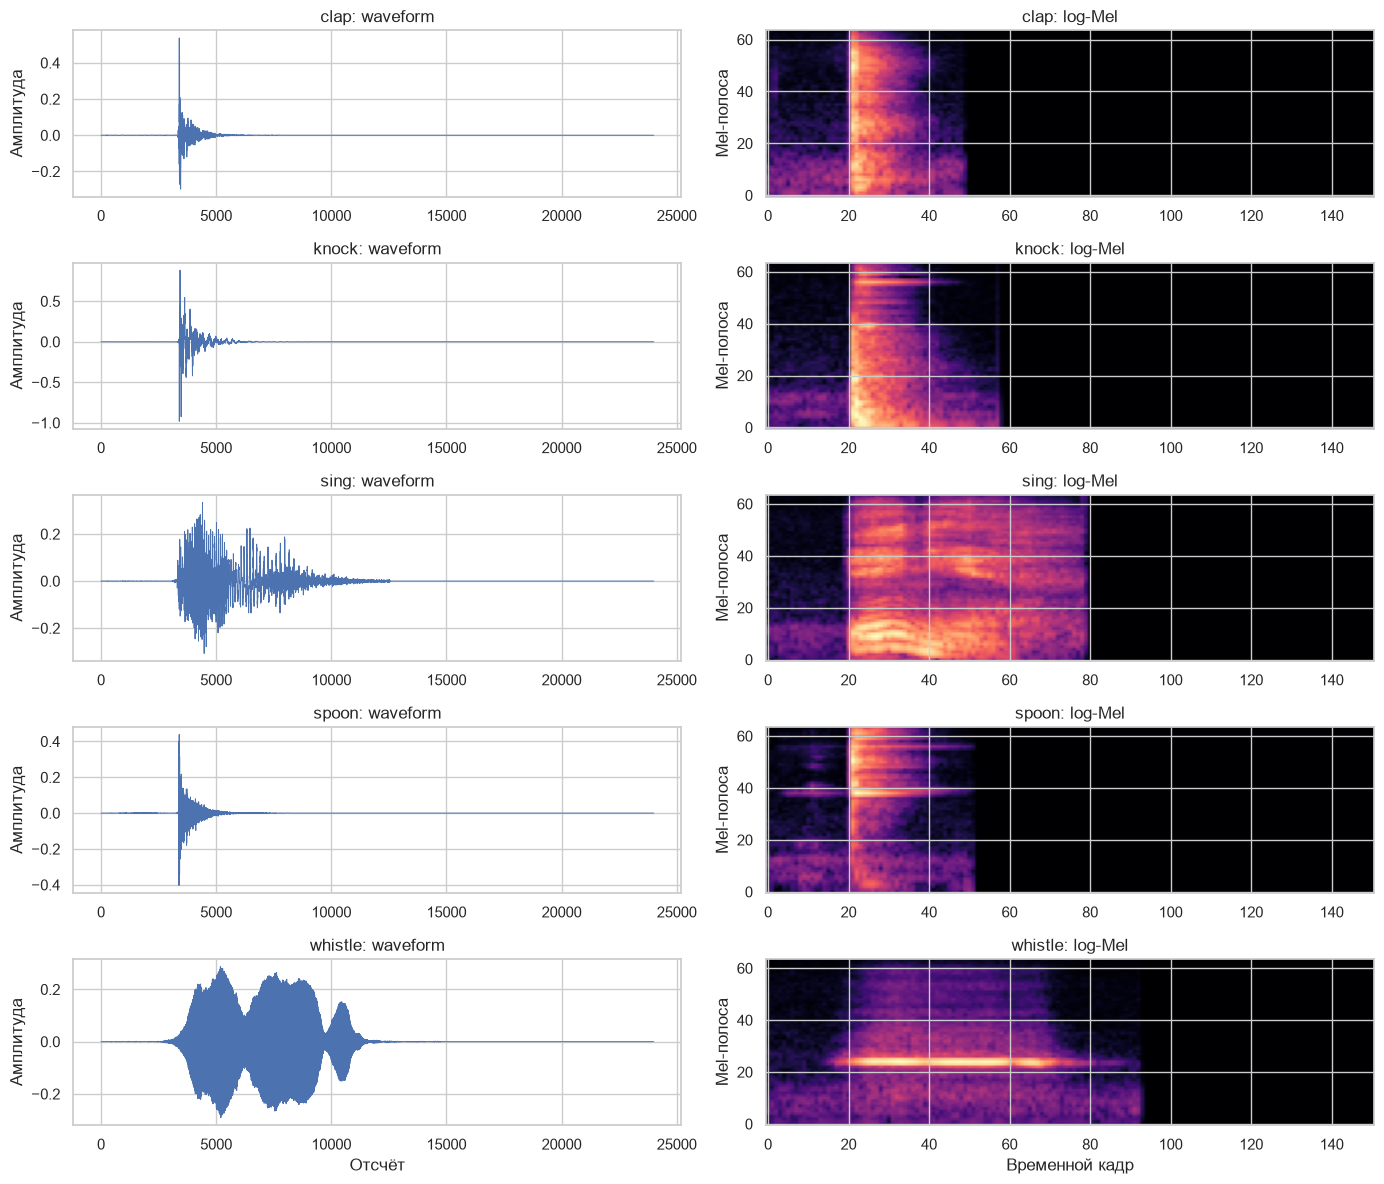

In [5]:
extractor = LogMelExtractor()
examples = (
    splits["train"].sort_values(["class", "session", "path"])
    .groupby("class", sort=False).head(1).set_index("class").loc[list(CLASS_NAMES)].reset_index()
)

fig, axes = plt.subplots(len(CLASS_NAMES), 2, figsize=(14, 12))
feature_rows = []
for row_index, row in examples.iterrows():
    path = ROOT / "data" / "raw" / row["path"]
    waveform = load_waveform(path)
    features = extractor(waveform)
    feature_rows.append({
        "class": row["class"],
        "waveform shape": tuple(waveform.shape),
        "feature shape": tuple(features.shape),
        "min": float(features.min()),
        "max": float(features.max()),
    })
    axes[row_index, 0].plot(waveform.squeeze().numpy(), linewidth=0.7)
    axes[row_index, 0].set(title=f"{row['class']}: waveform", ylabel="Амплитуда")
    axes[row_index, 1].imshow(features.squeeze().numpy(), origin="lower", aspect="auto", cmap="magma")
    axes[row_index, 1].set(title=f"{row['class']}: log-Mel", ylabel="Mel-полоса")
axes[-1, 0].set_xlabel("Отсчёт")
axes[-1, 1].set_xlabel("Временной кадр")
plt.tight_layout()
display(pd.DataFrame(feature_rows))
assert all(row["feature shape"] == (1, 64, 151) for row in feature_rows)

## 5. Sanity check финальных аугментаций

В train используются сдвиг до 20% длительности и gain ±9 dB. В validation/test аугментаций нет.
Шум не включён: ручная проверка сохраняла метку, но диагностическая модель показала сильную
деградацию устойчивости.

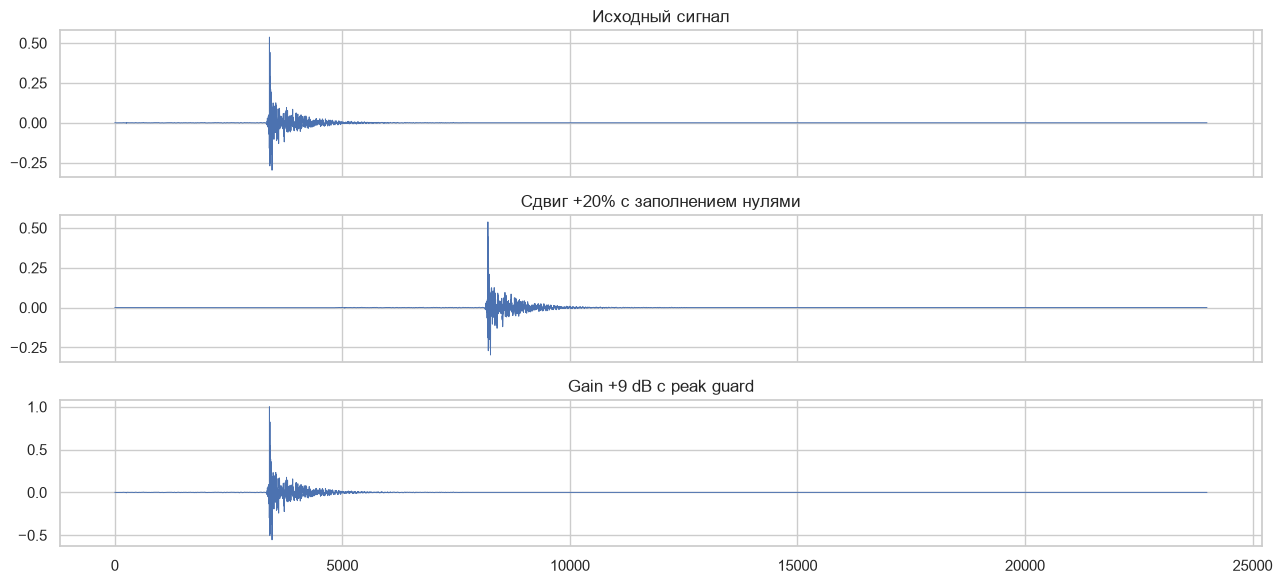

In [6]:
example_path = ROOT / "data" / "raw" / examples.iloc[0]["path"]
original = load_waveform(example_path)
shifted = shift_with_zeros(original, int(original.shape[-1] * 0.20))
gained = original * (10 ** (9.0 / 20.0))
gained = gained / gained.abs().max().clamp_min(1.0)

fig, axes = plt.subplots(3, 1, figsize=(13, 6), sharex=True)
for axis, signal, title in zip(
    axes,
    (original, shifted, gained),
    ("Исходный сигнал", "Сдвиг +20% с заполнением нулями", "Gain +9 dB с peak guard"),
):
    axis.plot(signal.squeeze().numpy(), linewidth=0.7)
    axis.set_title(title)
plt.tight_layout()

## Вывод

Датасет и метаданные согласованы. Разбиение проверяет перенос на новые условия записи, а не
запоминание соседних файлов. Обе архитектуры получают один и тот же тензор `[1, 64, 151]`;
различия итогового качества относятся к моделям и обучению, а не к разной предобработке.